# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

I (jimmy :]) use MCMC to compute the effects of suppressing tail terms (1.5-3.5PN order, encompassing first-order tails to 2nd-order nonlinear Christodoulou memory) in the waveform. Of interest are the Bayes factor between the untouched waveform and variously suppressed waveforms as a multivariate function of the toggling parameters (lambda15 thru lambda35).

## PN Terms by Order
- 1.5PN: first-order tail term; 
- 2.5PN: Christodoulou memory term and corrections to the 1.5PN tail term; 
- 3PN: second-order tail/tail-of-tail term; 
- 3.5PN: Christodoulou memory correction

In [4]:
import lambdasMCMC as lmcmc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import Akima1DInterpolator
import thermo_error as te

In [2]:
## Only NEED the <lnL> vs beta plot, but DO write functionality to make diagnostic plots like: 
# time/freq-series strain,
# \Delta\Psi vs f, **STARTED
# lnL vs iteration, **STARTED
# \vec{\theta} vs iteration, **STARTED
# MAYBE posterior corner plots (for 1-2 arbitrary sets of toggle params) and bayesograms
## Figure out how to calculate lnZ's later
num_samples=10000
num_chains=7
temp0=3.5
temp_ladder_structure='geometric'


######### Running PTMCMC #1/2 for lambdavec=$\lambda15$=0.0, $\lambda25$=0.0, $\lambda3$=0.0, $\lambda35$=0.0 #########
Jump acceptance rates
Fisher_jump: [0.69102402 0.66776233 0.65132743 0.64323641 0.61036662 0.55979772
 0.60505689]
DE_jump: [0.01012596 0.01210175 0.0125957  0.01481847 0.02025191 0.02667325
 0.04865399]
PT_swap: [0.16340852 0.1433584  0.17343358 0.13533835 0.15538847 0.17192982
 0.        ]
Chain 1 (T=1.0):
 	<lnL>_2-<lnL>_1=-7.085063900113062,
 	alpha(sigma_1+sigma_2)=2.690907351919695,
 	overlap w/ chain 2? False
Chain 2 (T=3.5):
 	<lnL>_3-<lnL>_2=-26.58322986903066,
 	alpha(sigma_2+sigma_3)=8.2694958133056,
 	overlap w/ chain 3? False
Chain 3 (T=12.25):
 	<lnL>_4-<lnL>_3=-94.49836870488983,
 	alpha(sigma_3+sigma_4)=29.9188389254201,
 	overlap w/ chain 4? False
Chain 4 (T=42.875):
 	<lnL>_5-<lnL>_4=-351.75992509166855,
 	alpha(sigma_4+sigma_5)=139.4967395558763,
 	overlap w/ chain 5? False
Chain 5 (T=150.062):
 	<lnL>_6-<lnL>_5=-1331.528245235971,
 	alpha(sigma_5+s

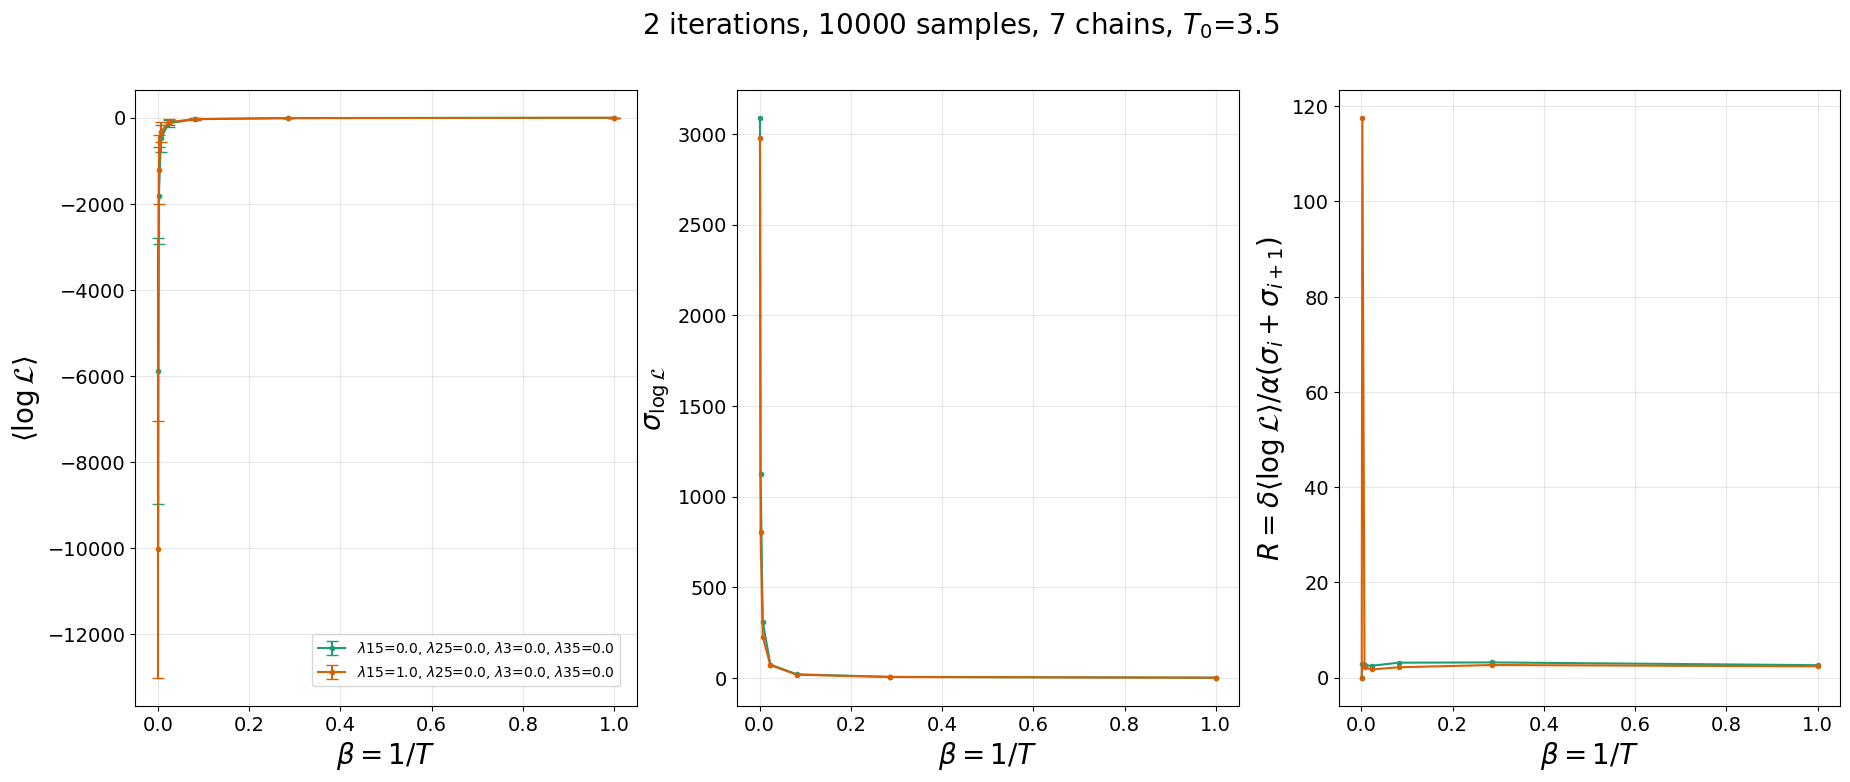

In [ ]:
### Plot <lnL> vs. \beta for each chosen vector of lambda values
lambdas=list(zip(lmcmc.lambda15s, lmcmc.lambda25s, lmcmc.lambda3s, lmcmc.lambda35s))
num_lmcmciters=len(lambdas)

fig,(ax1, ax2, ax3) = plt.subplots(1,3, figsize=(25,8))

colors=lmcmc.itercolors

__TIData__ = np.zeros(num_lmcmciters, dtype=lmcmc.TIData)

i=1
for lambda15, lambda25, lambda3, lambda35 in lambdas:
    lambdavec=rf'$\lambda15$={round(lambda15,2)}, $\lambda25$={round(lambda25,2)}, $\lambda3$={round(lambda3,2)}, $\lambda35$={round(lambda35,2)}'
    print(f'######### Running PTMCMC #{i}/{num_lmcmciters} for lambdavec={lambdavec} #########')

    ## Do PTMCMC for this set of lambda values
    samples, lnposts, temp_ladder, acc_rates = lmcmc.PTMCMC_i(lambdas=[lambda15, lambda25, lambda3, lambda35], 
                                                   num_samples=num_samples,
                                                   num_chains=num_chains,
                                                   temp0=temp0,
                                                   temp_ladder_structure=temp_ladder_structure)

    # Plot results
    betas, avg_lnlikes, lnlikes_stdevs = lmcmc.avglnlikes_vs_betas(temp_ladder, lnposts, num_samples)
    ax1.errorbar(betas, avg_lnlikes, yerr=lnlikes_stdevs, capsize=4, marker='.', color=colors[i-1], label=lambdavec)    
    ax2.plot(betas, lnlikes_stdevs, marker='.', color=colors[i-1], label=lambdavec)

    # save data (to be splined and then integrated)
    __TIData__[i-1]=lmcmc.TIData(np.flip(betas), np.flip(avg_lnlikes), np.flip(lnlikes_stdevs), lambdavec, colors[i-1]) # Akima splining strictly takes increasing lists for independent variables (betas)

    ## Inspect ladder spacing    
    # Overlap factors \alpha
    alphas=np.zeros(len(betas)-1)
    for j in range(len(betas)-1):
        avg_lnlike_1, avg_lnlike_2 = avg_lnlikes[j], avg_lnlikes[j+1]
        lnlikes_stdev_1, lnlikes_stdev_2 = lnlikes_stdevs[j], lnlikes_stdevs[j+1]
        alphas[j]=lmcmc.alpha_overlap(avg_lnlike_1, lnlikes_stdev_1, avg_lnlike_2, lnlikes_stdev_2)

    # R-statistic
    B,R=lmcmc.ladder_spacing_ratio(temp_ladder, avg_lnlikes, lnlikes_stdevs, alphas, print_chains=True, haxis='B')
    ax3.plot(B,R, marker='.', color=colors[i-1], label=lambdavec)

    # print average PT swap acceptance rate (just so it's easy to track by chain)
    avgPTswapaccrate=np.mean(acc_rates['PT_swap'][:-1])
    print(f'Average PT swap acceptance rate: {avgPTswapaccrate}')
    print(f'Alpha values for each chain: {list(zip(betas[:-1],alphas))}')

    i+=1 # finish iteration


# Decorate the plots :)
fig.suptitle(rf'{num_lmcmciters} iterations, {num_samples} samples, {num_chains} chains, $T_0$={temp0}', fontsize=20)
ax1.set_ylabel(r'$\langle\log\mathcal{L}\rangle$', fontsize=20)
ax1.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02))

ax2.set_ylabel(r'$\sigma_{\log\mathcal{L}}$', fontsize=20)

ax3.set_ylabel(r'$R = \delta\langle\log\mathcal{L}\rangle / \alpha(\sigma_{i}+\sigma_{i+1})$', fontsize=20)


for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.3)
    ax.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.show()

In [ ]:
### Evidence calculations (with Neil splining)

################## SCIPY IS BS; USE thermo_error.py #####################
# thermo_error.py only takes in a series of chains if they're organized in a .dat file in the format of logLchain.dat.
# It has helper functions for writing numpy arrays as .txt files



In [ ]:
'''### Splining <lnL> vs \beta for evidence calculation

################## SCIPY IS BS; USE thermo_error.py #####################
# thermo_error.py only takes in a series of chains if they're organized in a .dat file in the format of logLchain.dat.
# It has helper functions for writing numpy arrays as .txt files
# To run thermo_error I need to import argparse, pathlib, and __future__ (?)


fig, ax = plt.subplots(figsize=(14,7))
num_mciters=50
for i in range(num_lmcmciters):
    # make sure betas_i, avg_lnlikes_i, and lnlikes_stdevs_i are initialized and stored in previous cell
    TIData = __TIData__[i]
    betas, avg_lnlikes, lnlikes_stdevs = TIData.betas, TIData.avg_lnlikes, TIData.lnlikes_stdevs
    TIData.evidence=np.zeros(num_mciters)

    # generate randomly-perturbed <lnL> v \beta plots
    for j in range(num_mciters):
        avg_lnlikes_akima_in = TIData.generatePerturbedLogLikesToSpline()
        betas_akima = np.linspace(min(betas), max(betas), num=100000)
        # Akima-spline the perturbed curve
        avg_lnlikes_akima_out = Akima1DInterpolator(betas, avg_lnlikes_akima_in, method="akima")
        # integrate under curve
        TIData.evidence[j]=avg_lnlikes_akima_out.integrate(min(betas),max(betas), extrapolate=False)
        # plot Akima-splined <lnL> v \beta
        ax.plot(betas_akima, avg_lnlikes_akima_out(betas_akima), marker=None, color=TIData.color, alpha=0.1)
    
    #print(f'Log-Evidence samples from lambdavec iteration #{i+1}: {TIData.evidence}')


#########################################################
fig.legend(loc='lower right', bbox_to_anchor=(0.98,0.02))
# ^^ make custom labels ^^ ##############################

ax.set_title(r'MC Splining of $\langle\log\mathcal{L}\rangle$ vs. $\beta$', size=30)
ax.set_xlabel(r'$\beta = 1/T$', size=20)    
ax.set_ylabel(r'$\langle\log\mathcal{L}\rangle$', size=20)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(alpha=0.3)

ax.set_xlim(-0.0002,0.02)

plt.show()

fig2,ax2=plt.subplots(figsize=(10,7))
for TIData in __TIData__:
    ax2.hist(TIData.evidence, color=TIData.color, alpha=0.5)
ax2.set_title(r'MC Measurements of $\log\mathcal{Z}$', size=20)
ax2.set_xlabel(r'$\log\mathcal{Z}$', size=20)    
ax2.set_ylabel(r'$N$', size=20)
ax2.tick_params(axis='both', which='major', labelsize=14)
plt.show()



In [ ]:
'''### Ladder spacing optimization

# Perform PTMCMCs and calculate mean PT swap rates w/ variance for S random num_chain and T0 values, then make a SCATTERPLOT with COLORS

S=100 # computation time is about 2hr/100 iterations

# independent variables
Ncs=np.zeros(S)
T0s=np.zeros(S)
# dependent variables
swaprate_avgs=np.zeros(S)
swaprate_stds=np.zeros(S)

fig, (ax1, ax2)=plt.subplots(1,2, figsize=(14,6))

### Get PT swap acceptance rates
for i in range(S):
    print(rf'######### Running PTMCMC #{i+1}/{S} #########')
    ## Do PTMCMC without any suppression for simplicity
    num_chains=np.random.randint(5,12)
    temp0=np.random.uniform(2,6)
    samples, lnposts, temp_ladder, acc_rates = lmcmc.PTMCMC_i(lambdas=[0,0,0,0], 
                                                   num_samples=10000,
                                                   num_chains=num_chains,
                                                   temp0=temp0)
    
    ## Inspect ladder spacing
    # ...

    ## save PT swap acceptance rates
    PTswapaccrate_avg=np.mean(acc_rates['PT_swap'][:-1])
    PTswapaccrate_var=np.std(acc_rates['PT_swap'][:-1])
    
    Ncs[i]=num_chains
    T0s[i]=temp0
    swaprate_avgs[i]=PTswapaccrate_avg
    swaprate_stds[i]=PTswapaccrate_var

### create plot for averages
sc1 = ax1.scatter(
    Ncs,
    T0s,
    c=swaprate_avgs,      # values that determine color
    cmap="magma",         # seaborn colormap
    s=25                  # marker size (optional)
)

cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label("Mean PT Swap Acceptance Rate")

ax1.set_xlabel(r"Number of Chains $N_c$")
ax1.set_ylabel(r"$T_0$")

# create plot for variances
sc2 = ax2.scatter(
    Ncs,
    T0s,
    c=swaprate_stds,      # values that determine color
    cmap="viridis",         # seaborn colormap
    s=25                  # marker size (optional)
)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label("PT Swap Acceptance Rate Standard Deviation")

ax2.set_xlabel(r"Number of Chains $N_c$")
ax2.set_ylabel(r"$T_0$")
fig.suptitle("PT Swap Rate Across PTMCMC Configurations", fontsize=20)

plt.show()